# 1 — Introduction and the ANNNI-type model

**Long-time dynamics of a quantum many-body system via transverse contraction**  
Master's thesis by Joaquín G. Márquez Olguín 
Supervisor: Stefano Carignano (BSC)

---

How does a closed quantum system relax (thermalize) after a sudden quench? In generic non-integrable systems, the answer is governed by the Eigenstate Thermalization Hypothesis (ETH): local observables scramble and reach thermal values. Because exact analytic solutions are restricted to integrable limits, exploring thermalization in non-integrable models relies almost entirely on our ability to track their **long-time dynamics numerically**.

Tensor networks provide a promising framework to tackle this problem by using entanglement as the organizing principle. For 1D systems in equilibrium, Matrix Product States (MPS), alongside with many powerful algorithms to manipulate and update them, have proved to be very successful, becoming the state-of-the-art. This sucess is mainly due to the **area law**: the entanglement entropy across a cut in an MPS saturates to a constant, so a modest bond dimension represents the state faithfully. Out of equilibrium, however, the entanglement entropy typically grows **linearly in time** (following what is known as a volume law). This is the **entanglement barrier**: standard time-evolution algorithms (TEBD, TDVP) are excellent at short times but require an exponentially growing bond dimension at late times, which bottlenecks every computation.

**Transverse contraction** is a promising new idea that tries to overcome this barrier. The key idea is that the full dynamics (of a 1D system) can be encoded as a 2D tensor network in which time is considered a second spatial dimension. Contracting it along the original spatial direction then gives the desired dynamics. The cost is set not by the spatial entanglement but by a new quantity, the *temporal* entanglement entropy (whose physical meaning is still under study). From CFT results, we know that at a critical point, this grows only logarithmically.

This thesis asks whether that favourable (logarithmic) behaviour, established for integrable critical chains, survives the breaking of integrability. We answer this by styding the ANNNI-type (Alcaraz) model introduced below.

This first notebook presents the model and shows why the naive route to its time evolution fails, motivating the dedicated exponential-MPO construction of notebook 2.

## The ANNNI-type (Alcaraz) model

We study a self-dual spin-$1/2$ chain that extends the transverse-field Ising model with
next-nearest-neighbour (NNN) couplings of strength $p$:

$$ H = -\sum_i \left( \sigma_i^z \sigma_{i+1}^z + p\,\sigma_i^z \sigma_{i+2}^z
        + \lambda\,\sigma_i^x + p\lambda\,\sigma_i^x \sigma_{i+1}^x \right). $$

- $\lambda$ is the transverse field; the critical point sits at $\lambda = 1$ for every $p$ studied (*Alcaraz (2016)* shows it should stay critical for at least $p=1.5$, see original paper for details).
- $p$ controls the NNN coupling. At $p=0$, the model reduces exactly to the integrable
  transverse-field Ising model (TFIM). Any $p>0$ introduces a second interaction length scale and
  thus breaks integrability.
- The $p\lambda\,\sigma^x\sigma^x$ term is required to preserve self-duality,
  $H(\lambda,p) = \lambda\, H(1/\lambda,p)$.

We have shown (verified by DMRG in notebook 4) that the model stays critical and in the Ising
universality class ($c \approx 1/2$) over a wide range of $p$, so the conformal-field-theory
(CFT) predictions we will test still have a well-defined target.

**Convention.** Here the field couples to $\sigma^x$ and the interaction to $\sigma^z$ — the
*opposite* basis to the Ising convention built into `ITransverse.jl` (field on $\sigma^z$,
coupling on $\sigma^x$). The two are related by a $\pi/2$ rotation $\sigma^x\leftrightarrow\sigma^z$,
which is why our initial state and operators are written in the $\sigma^x$ basis.

**Quench protocol.** We prepare the polarized paramagnet
$|\Psi_0\rangle = |X+\rangle^{\otimes N}$ — the ground state of $H$ as $\lambda\to\infty$ — and
quench to the critical point $\lambda=1$. The central observable is the **Loschmidt echo**
$\mathcal{L}(t) = \langle\Psi_0| e^{-iHt} |\Psi_0\rangle$, the return amplitude (a complex number,
not its modulus).

In [ ]:
include("src/thesislib.jl")

# Reference parameters
lambda = 1.0     # critical point
p      = 0.1     # NNN coupling
dt     = 0.1     # Trotter step

alcaraz_opsum(6, lambda, p)

sum(
  -1.0 Z(1,) Z(2,)
  -0.1 X(1,) X(2,)
  -1.0 Z(2,) Z(3,)
  -0.1 X(2,) X(3,)
  -1.0 Z(3,) Z(4,)
  -0.1 X(3,) X(4,)
  -1.0 Z(4,) Z(5,)
  -0.1 X(4,) X(5,)
  -1.0 Z(5,) Z(6,)
  -0.1 X(5,) X(6,)
  -0.1 Z(1,) Z(3,)
  -0.1 Z(2,) Z(4,)
  -0.1 Z(3,) Z(5,)
  -0.1 Z(4,) Z(6,)
  -1.0 X(1,)
  -1.0 X(2,)
  -1.0 X(3,)
  -1.0 X(4,)
  -1.0 X(5,)
  -1.0 X(6,)
)

## Time evolution, the naive way: Trotter gates

The textbook approach is a Suzuki–Trotter decomposition: write $U(t)=\prod U(\delta t)$ and split
each short step into a brick-wall of two-site gates, which we apply to the MPS and re-compress by
SVD truncation at every step (TEBD). This works beautifully for nearest-neighbour models. The NNN
coupling $\sigma_i^z\sigma_{i+2}^z$ breaks it: the interaction does not live on a single bond, so
it cannot be placed in a clean two-site brick-wall. One is forced either to group three sites into
one gate (the awkward $\sigma^z\!\otimes\mathbb{1}\otimes\sigma^z$ gate below) or to insert SWAP
gates to bring the non-adjacent spins together — both inflate the entanglement and degrade the
result.

To make the failure quantitative we benchmark this naive TEBD against **TDVP**, our trusted
reference, through the central-spin magnetization $\langle\sigma^z_{N/2}\rangle(t)$ after the
quench. The TDVP run is expensive, so we reuse a **cached** result
(`results/data/tvdp_run.jld2`); the cheap Trotter curve is recomputed live. For this benchmark we
use the legacy demo setup ($N=50$, $p=0.5$, initial state $|\!\uparrow\rangle$, measuring
$\sigma^z$) so it matches the cached run — the production thesis convention ($|X+\rangle$, $p=0.1$,
the Loschmidt echo) resumes from notebook 3 onward.

The helper below is the *highly specific* local gate builder for this naive attempt (kept local to
this notebook, not in the library): a symmetric second-order Trotter step with the three-site NNN
gate carrying an identity on the intermediate site.

In [2]:
# Local helper (naive TEBD): symmetric 2nd-order Trotter gates, with the awkward 3-site NNN gate.
function build_alcaraz_gates(sites, lambda::Float64, p::Float64, dt::Float64)
    N = length(sites); dt_half = dt/2; gates = ITensor[]
    for j in 1:N-2   # half-step NNN (3-site gate Z⊗Id⊗Z — the awkward part)
        h = -p * op("Z", sites[j]) * op("Id", sites[j+1]) * op("Z", sites[j+2])
        push!(gates, exp(-im*dt_half*h))
    end
    for j in 1:N-1   # half-step NN (ZZ + p*lambda*XX)
        h = -1.0*op("Z",sites[j])*op("Z",sites[j+1]) - p*lambda*op("X",sites[j])*op("X",sites[j+1])
        push!(gates, exp(-im*dt_half*h))
    end
    for j in 1:N     # full-step transverse field
        push!(gates, exp(-im*dt*(-lambda*op("X", sites[j]))))
    end
    for j in N-1:-1:1   # mirror the half-steps (symmetric Trotter)
        h = -1.0*op("Z",sites[j])*op("Z",sites[j+1]) - p*lambda*op("X",sites[j])*op("X",sites[j+1])
        push!(gates, exp(-im*dt_half*h))
    end
    for j in N-2:-1:1
        h = -p * op("Z", sites[j]) * op("Id", sites[j+1]) * op("Z", sites[j+2])
        push!(gates, exp(-im*dt_half*h))
    end
    return gates
end

build_alcaraz_gates (generic function with 1 method)

### Benchmark: naive Trotter vs TDVP

The first code cell defines the TDVP reference (loaded from `results/data/tvdp_run.jld2`; pass
`force=true` to recompute it). The second runs the naive Trotter evolution live and overlays the
two central-spin curves. The agreement is **surprisingly good at short times** — the second-order
Trotter decomposition captures the early dynamics well — but the approach is still **fundamentally
unsuitable** for the transverse method, for structural reasons explained below.

In [ ]:
# TDVP reference for ⟨σᶻ₍N/2₎⟩ (the trusted yardstick). Cached — set force=true to regenerate.
function tdvp_z_reference(; N=50, lambda=1.0, p=0.5, dt=0.1, T_max=3.0,
                          cutoff=1e-12, maxdim=200,
                          cachefile="results/data/tvdp_run.jld2", force=false)
    (!force && isfile(cachefile)) && return load(cachefile)
    sites = siteinds("S=1/2", N); center = N ÷ 2
    H   = MPO(alcaraz_opsum(N, lambda, p), sites)
    psi = MPS(sites, "Up")
    times_tdvp = collect(dt:dt:T_max); z_tdvp = Float64[]
    @showprogress "TDVP ⟨Z⟩" for _ in times_tdvp
        psi = tdvp(H, -im*dt, psi; cutoff=cutoff, maxdim=maxdim, nsweeps=2)
        push!(z_tdvp, real(expect(psi, "Z")[center]))
    end
    jldsave(cachefile; times_tdvp, z_tdvp, p_value=p, lambda_value=lambda)
    return load(cachefile)
end

# Loads the cache if present; only runs TDVP when forced or the file is missing.
tdvp_z_reference();

naive TEBD ⟨Z⟩ 100%|█████████████████████████████████████| Time: 0:05:24


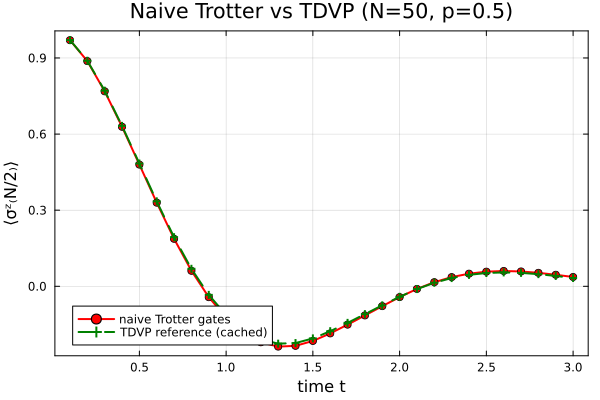

In [3]:
# Naive TEBD run (cheap, computed live) and overlay against the cached TDVP reference.
N = 50
lambda_d = 1.0
p_d = 0.5
dt_d = 0.1
T_max = 3.0

sites  = siteinds("S=1/2", N); center = N ÷ 2
gates  = build_alcaraz_gates(sites, lambda_d, p_d, dt_d)
times  = collect(dt_d:dt_d:T_max)

psi = MPS(sites, "Up"); z_trotter = Float64[]
@showprogress "naive TEBD ⟨Z⟩" for _ in times
    global psi = apply(gates, psi; cutoff=1e-12, maxdim=200)
    normalize!(psi)
    push!(z_trotter, real(expect(psi, "Z")[center]))
end

ref = load("results/data/tvdp_run.jld2")          # cached TDVP ⟨Z⟩ (heavy; not recomputed here)
plt = plot(times, z_trotter; lw=2, marker=:circle, color=:red, label="naive Trotter gates",
           xlabel="time t", ylabel="⟨σᶻ₍N/2₎⟩", framestyle=:box, grid=true, legend=:bottomleft,
           title="Naive Trotter vs TDVP (N=$N, p=$p_d)")
plot!(plt, ref["times_tdvp"], ref["z_tdvp"]; lw=2, marker=:cross, ls=:dash, color=:green,
      label="TDVP reference (cached)")
plt

### Why the naive route is not enough

The benchmark above shows that the naive Trotter gates track TDVP **reasonably well** for the
central-spin observable $\langle\sigma^z_{N/2}\rangle(t)$ — a relief that confirms the gate
construction is correct. But accuracy of the *state evolution* is not the bottleneck; the problems
are structural:

1. **Transverse contraction needs a translation-invariant MPO.** If we collapse the gate layer into
   a single time-step MPO by `apply`-ing the gates onto an identity MPO, the global SVD inside
   `apply` shifts the gauge and the resulting tensor is **no longer site-independent**. Transverse
   contraction rotates this MPO by $90^\circ$ and reuses one *identical* column as the spatial
   transfer matrix, so any residual site dependence breaks the method outright.

2. **No truncation $\Rightarrow$ exponential blow-up.** A genuinely exact global apply keeps every
   Schmidt value, so the bond dimension explodes; truncating, on the other hand, reintroduces the
   gauge problem above and an uncontrolled error for the NNN cross-terms.

The clean fix is to abandon spatial Trotterization and build the time-step operator $U(\delta t)$
**directly as a uniform MPO** from a finite-state-machine encoding of $H$ — but first we make the
reliability of our TDVP yardstick — and its limits — explicit.

## The reliable reference: TDVP, and the entanglement barrier

The naive Trotter benchmark tracked TDVP well — confirming the gate construction is correct. But
TDVP itself pays the full cost of the entanglement barrier: the bond dimension it needs grows with
the spatial entanglement of the evolving state. The cached run below makes this concrete — the
Loschmidt rate is essentially flat ($\ell\approx0.10$), but the bond dimension climbs
$\chi: 8 \to 29 \to 107 \to 256$ and **saturates the cap by $T\approx4.5$**, beyond which the
answer is no longer converged. This is precisely the wall transverse contraction is designed to
avoid.

## Takeaways

- The ANNNI-type model is fixed by the Hamiltonian above; we quench from $|X+\rangle^{\otimes N}$
  to $\lambda=1$ and track the Loschmidt echo.
- **Naive Trotter TEBD reproduces the dynamics reasonably well** (the Trotter-vs-TDVP benchmark
  agrees), confirming the gate construction is correct — but it is **structurally unsuitable** for
  transverse contraction because the global `apply` breaks translation invariance.
- **TDVP is a reliable reference but hits the entanglement barrier**: its bond dimension saturates
  the cap by $T\approx4.5$, so the Schrödinger picture cannot reach the late times we care about.

Notebook 2 builds the translation-invariant exponential MPO (the WII and VD2 constructions),
benchmarks it against TDVP, and shows how it becomes the column of the transverse network.

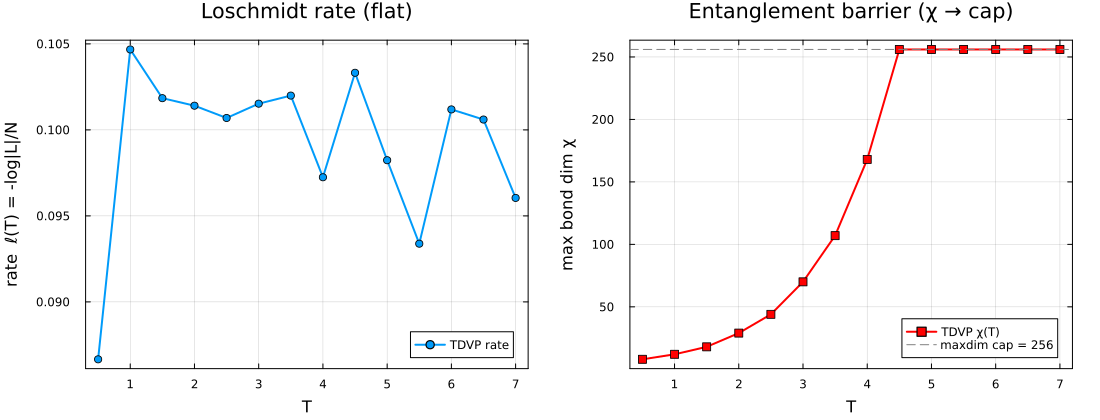

In [5]:
# Reuse the cached TDVP Loschmidt run (Alcaraz p=0.1, N=40, dt=0.05).
# (Regenerate from scratch with:  tdvp_loschmidt_amplitude(40, collect(0.5:0.5:7.0); p=0.1) )
tdvp = load("results/data/tdvp_loschmidt_p0.1_N40.jld2", "done")
Ts   = sort(collect(keys(tdvp)))
rate = [tdvp[T].rate   for T in Ts]
chi  = [tdvp[T].maxchi for T in Ts]

pr = plot(Ts, rate; xlabel="T", ylabel="rate  ℓ(T) = -log|L|/N", lw=2, marker=:circle,
          label="TDVP rate", framestyle=:box, grid=true, title="Loschmidt rate (flat)")
pc = plot(Ts, chi;  xlabel="T", ylabel="max bond dim χ", lw=2, marker=:square, color=:red,
          label="TDVP χ(T)", framestyle=:box, grid=true, title="Entanglement barrier (χ → cap)")
hline!(pc, [256]; ls=:dash, color=:gray, label="maxdim cap = 256")
plot(pr, pc; layout=(1,2), size=(1100,420), margin=5Plots.mm)